# Cross Validation of NMF

In [1]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import os

sns.set("talk", "ticks", palette='colorblind')

## Write the Nonnegative Matrix Factorization Code that can handle missing data

In [2]:
from nnls import nnlsm_blockpivot as nnlstsq

def censored_nnlstsq(A, B, M):
    """Solves nonnegative least-squares problem with missing data in B
    Args
    ----
    A (ndarray) : m x r matrix
    B (ndarray) : m x n matrix
    M (ndarray) : m x n binary matrix (zeros indicate missing values)

    Returns
    -------
    X (ndarray) : nonnegative r x n matrix that minimizes norm(M*(AX - B))
    """
    if A.ndim == 1:
        A = A[:, None]

    rhs = np.dot(A.T, M * B).T[:, :, None] # n x r x 1 tensor
    T = np.matmul(A.T[None,:,:], M.T[:,:,None] * A[None,:,:]) # n x r x r tensor
    X = np.empty((B.shape[1], A.shape[1]))

    for n in range(B.shape[1]):
        X[n] = nnlstsq(T[n], rhs[n], is_input_prod=True)[0].T

    return X.T


def cv_nmf(data, rank, M=None, p_holdout=0.3, tol=0.001, verbose=False, max_iter=50):
    """Perform cross-validation for NMF using a speckled holdout pattern.

    This code was adapted from Alex Williams at Stanford (https://bit.ly/2KDqKoW).

    Args
    ----
    data (ndarray)    : m x n matrix (original data/time-series)
    rank (int)        : the desired output rank (i.e. number of factors)
    M (ndarray)       : m x n binary matrix where zeroes indicate missing/heldout values
    p_holdout (float) : all random data under this value will be set to False
    tol (float)       : the tolerance for convergence - the solution has converged when
                        the MSE of subsequent iterations are less than this number
    verbose (bool)    : if True, print out debugging information
    max_itr (int)     : the maximum number of iterations for convergence

    Returns
    -------
    U (ndarray)       :
    Vt (ndarray)      :
    train_err (float) :
    test_err (float)  :
    converged (bool)  :

    """

    # create the masking matrix to decide which values to "hold out"
    if M is None:
        M = np.random.rand(*data.shape) > p_holdout

        # check to make sure there are enough values in each row to avoid singular matrix issues
        if M.sum(axis=0).any() < rank:
            for i in range(M.shape[0]):
                if M[i].sum() < rank:
                    M[i, :] = [True]*M.shape[1]

    # initialize U randomly
    U = np.random.rand(data.shape[0], rank)

    # init the mean err
    mse = 100

    # fit NMF
    for itr in range(max_iter):
        Vt = censored_nnlstsq(U, data, M)
        U = censored_nnlstsq(Vt.T, data.T, M.T).T

        # calculate the current iterations mean squared error
        tmp_mse = np.mean((np.dot(U, Vt) - data)**2)
        diff = mse - tmp_mse

        # break out of the loop if converged
        if abs(diff) <= tol:
            converged = True
            break
        else:
            mse = tmp_mse
            converged = False

    if verbose:
        train_pct = 100 * M.sum() / M.size
        print ("\tIter {} = {:.5f}".format(itr+1, diff))
        print ("\tTrain/Test = {:.2f}/{:.2f}".format(train_pct, 100-train_pct))

    # return the result and the train/test error
    resid = np.dot(U, Vt) - data
    train_err = np.mean(resid[M]**2)
    test_err = np.mean(resid[~M]**2)

    return U, Vt, train_err, test_err, converged

## Let's try an example...

In [3]:
N, R = 150, 4

noise = 0.8
replicates = 10

ranks = np.arange(1, 8)

# initialize the problem
U = np.random.rand(N, R) # (150, 4)
Vt = np.random.rand(R, N) # (4, 150)

# create the data by making it noisy
data = np.dot(U, Vt) + noise * np.random.rand(N, N) # (150, 150)

frame = pd.DataFrame()

# fit the models
for rnk, _ in itertools.product(ranks, range(replicates)):
    tr, te, converged = cv_nmf(data, rnk, verbose=False)[2:]

    if converged:

        new_rows = pd.DataFrame([
            {"Rank": rnk, "MSE": tr, "Group": "Train"},
            {"Rank": rnk, "MSE": te, "Group": "Test"},])

        frame = pd.concat([frame, new_rows], ignore_index=True)

    else:
        print ("there was a convergence issue: {}".format(rnk))

frame["Rank"] = frame["Rank"].astype(np.int32)

# prepare for plotting
groups = frame.groupby(["Group", "Rank"]).describe(percentiles=[0.05, 0.95])

In [4]:
groups

MSE                                                              \
           count      mean       std       min        5%       50%       95%   
Group Rank                                                                     
Test  1     10.0  0.076638  0.001022  0.074665  0.075223  0.076701  0.077881   
      2     10.0  0.071101  0.000885  0.069369  0.069736  0.071285  0.072189   
      3     10.0  0.063854  0.000951  0.062464  0.062480  0.063943  0.065088   
      4     10.0  0.059311  0.000531  0.058461  0.058601  0.059379  0.060016   
      5     10.0  0.060828  0.000678  0.059803  0.059934  0.060896  0.061665   
      6     10.0  0.062756  0.000470  0.061723  0.061964  0.062818  0.063257   
      7     10.0  0.064172  0.000968  0.062823  0.062840  0.064055  0.065489   
Train 1     10.0  0.073752  0.000439  0.073068  0.073185  0.073756  0.074344   
      2     10.0  0.065298  0.000563  0.064390  0.064492  0.065298  0.066070   
      3     10.0  0.057396  0.000701  0.056622  0.056638  0.057295  0.058544   
      4     10.0  0.050236  0.000267  0.049891  0.049955  0.050197  0.050632   
      5     10.0  0.048785  0.000181  0.048500  0.048572  0.048774  0.049057   
      6     10.0  0.047259  0.000327  0.046743  0.046819  0.047382  0.047606   
      7     10.0  0.045740  0.000296  0.045376  0.045396  0.045622  0.046167   

                      
                 max  
Group Rank            
Test  1     0.078058  
      2     0.072192  
      3     0.065215  
      4     0.060140  
      5     0.061815  
      6     0.063435  
      7     0.065978  
Train 1     0.074588  
      2     0.066354  
      3     0.058633  
      4     0.050823  
      5     0.049207  
      6     0.047617  
      7     0.046234

## Plot the results

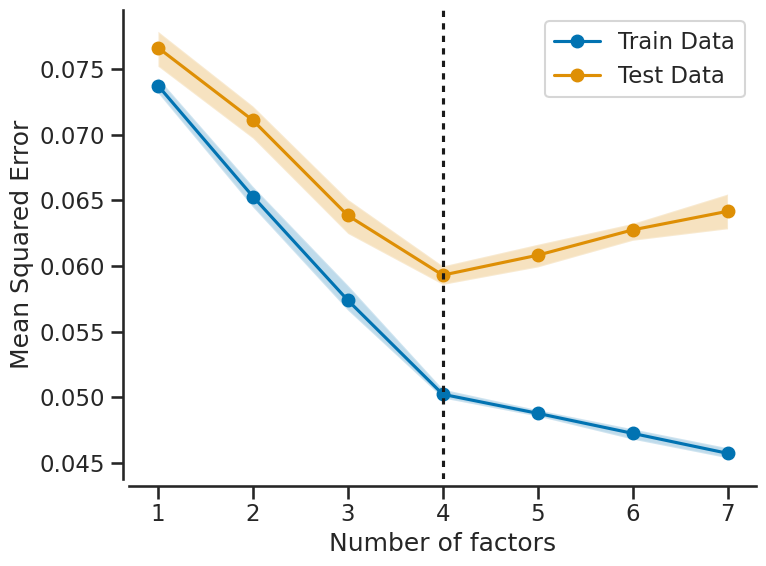

In [5]:
fig, ax = plt.subplots(1, figsize=(8, 6))

ax.plot(groups["MSE"]["mean"]["Train"], 'o-', label="Train Data")
ax.plot(groups["MSE"]["mean"]["Test"], 'o-', label="Test Data")

ax.fill_between(groups["MSE"]["5%"]["Train"].index, groups["MSE"]["5%"]["Train"],
                groups["MSE"]["95%"]["Train"], alpha=0.25)
ax.fill_between(groups["MSE"]["5%"]["Test"].index, groups["MSE"]["5%"]["Test"],
                groups["MSE"]["95%"]["Test"], alpha=0.25)

inflection = (groups["MSE"]["mean"]["Test"] > groups["MSE"]["mean"]["Test"].shift()).idxmax() - 1

ax.axvline(inflection, color='k', dashes=[2, 2])

sns.despine(offset=5)
ax.set_ylabel("Mean Squared Error")
ax.set_xlabel("Number of factors")
ax.legend()
plt.tight_layout()

## Trying on Our Data

In [6]:
from nnls import nnlsm_blockpivot as nnlstsq

def censored_nnlstsq2(A, B, M):
    """Solves nonnegative least-squares problem with missing data in B
    Args
    ----
    A (ndarray) : m x r matrix
    B (ndarray) : m x n matrix
    M (ndarray) : m x n binary matrix (zeros indicate missing values)

    Returns
    -------
    X (ndarray) : nonnegative r x n matrix that minimizes norm(M*(AX - B))
    """
    if A.ndim == 1:
        A = A[:, None]

    rhs = np.dot(A.T, M * B).T[:, :, None] # n x r x 1 tensor
    T = np.matmul(A.T[None,:,:], M.T[:,:,None] * A[None,:,:]) # n x r x r tensor
    X = np.empty((B.shape[1], A.shape[1]))

    for n in range(B.shape[1]):
        try:
            X[n] = nnlstsq(T[n], rhs[n], is_input_prod=True)[0].T
        except np.linalg.LinAlgError:
            X[n] = np.zeros((A.shape[1],))

    return X.T

def cv_nmf2(data, rank, M=None, p_holdout=0.3, tol=0.001, verbose=False, max_iter=50):
    """Perform cross-validation for NMF using a speckled holdout pattern.

    This code was adapted from Alex Williams at Stanford (https://bit.ly/2KDqKoW).

    Args
    ----
    data (ndarray)    : m x n matrix (original data/time-series)
    rank (int)        : the desired output rank (i.e. number of factors)
    M (ndarray)       : m x n binary matrix where zeroes indicate missing/heldout values
    p_holdout (float) : all random data under this value will be set to False
    tol (float)       : the tolerance for convergence - the solution has converged when
                        the MSE of subsequent iterations are less than this number
    verbose (bool)    : if True, print out debugging information
    max_itr (int)     : the maximum number of iterations for convergence

    Returns
    -------
    U (ndarray)       :
    Vt (ndarray)      :
    train_err (float) :
    test_err (float)  :
    converged (bool)  :

    """
    # create the masking matrix to decide which values to "hold out"

    if M is None:
        M = np.random.rand(*data.shape) > p_holdout
        min_valid = rank + 1

        # check to make sure there are enough values in each row to avoid singular matrix issues
        # iterate over each row, and if the row contains less True values than rank
            # turn that row to all True values

        for i in range(M.shape[0]):
            if M[i].sum() < min_valid:
                needed = min_valid - M[i].sum()
                zero_indices = np.where(~M[i])[0]
                if len(zero_indices) >= needed:
                    M[i, np.random.choice(zero_indices, size=int(needed), replace=False)] = True

        for j in range(M.shape[1]):
            if M[:, j].sum() < min_valid:
                needed = min_valid - M[:, j].sum()
                zero_indices = np.where(~M[:, j])[0]
                if len(zero_indices) >= needed:
                    M[np.random.choice(zero_indices, size=int(needed), replace=False), j] = True

    # initialize U randomly
    U = np.random.rand(data.shape[0], rank)

    # init the mean err
    mse = 100

    # fit NMF
    for itr in range(max_iter):
        Vt = censored_nnlstsq2(U, data, M)
        U = censored_nnlstsq2(Vt.T, data.T, M.T).T

        # calculate the current iterations mean squared error
        tmp_mse = np.mean((np.dot(U, Vt) - data)**2)
        diff = mse - tmp_mse

        # break out of the loop if converged
        if abs(diff) <= tol:
            converged = True
            break
        else:
            mse = tmp_mse
            converged = False

    if verbose:
        train_pct = 100 * M.sum() / M.size
        print ("\tIter {} = {:.5f}".format(itr+1, diff))
        print ("\tTrain/Test = {:.2f}/{:.2f}".format(train_pct, 100-train_pct))

    # return the result and the train/test error
    resid = np.dot(U, Vt) - data
    train_err = np.mean(resid[M]**2)
    test_err = np.mean(resid[~M]**2)

    return U, Vt, train_err, test_err, converged

In [7]:
#importing data from Modulair MOD-00689
df = pd.read_csv('MOD-00689.csv')
df.head()

,timestamp,id,timestamp_local,sn,rh,temp,bin0,bin1,bin2,bin3,...,no2,o3,pm1_model_id,pm25_model_id,pm10_model_id,co_model_id,no_model_id,no2_model_id,o3_model_id,ws_scalar
0,2025-12-31T23:59:05Z,577612306,2025-12-31T18:59:05Z,MOD-00689,49.6,0.5,6.743,0.692,0.187,0.038,...,29.938,38.903,14340.0,14341.0,14342.0,14476.0,14501.0,14551.0,14526.0,0.90
1,2025-12-31T23:58:05Z,577610344,2025-12-31T18:58:05Z,MOD-00689,49.7,0.5,7.506,0.821,0.251,0.027,...,29.223,39.248,14340.0,14341.0,14342.0,14476.0,14501.0,14551.0,14526.0,0.97
2,2025-12-31T23:57:05Z,577610343,2025-12-31T18:57:05Z,MOD-00689,49.8,0.4,7.911,0.835,0.231,0.051,...,29.449,39.248,14340.0,14341.0,14342.0,14476.0,14501.0,14551.0,14526.0,1.61
3,2025-12-31T23:56:05Z,577610342,2025-12-31T18:56:05Z,MOD-00689,50.0,0.4,7.611,0.901,0.256,0.050,...,29.677,38.185,14340.0,14341.0,14342.0,14476.0,14501.0,14551.0,14526.0,1.54
4,2025-12-31T23:55:05Z,577610341,2025-12-31T18:55:05Z,MOD-00689,49.9,0.4,8.115,0.936,0.324,0.078,...,30.155,38.190,14340.0,14341.0,14342.0,14476.0,14501.0,14551.0,14526.0,1.50


In [9]:
start = df['timestamp'].min()
print(start)

2025-04-01T00:00:58Z


In [10]:
#only including columns of interest and non na rows
COLS_TO_INCLUDE = ['timestamp_local','co', 'no2', 'o3', 'no', 'bin0', 'bin1', 'bin2','bin3','bin4','bin5']
df = df[COLS_TO_INCLUDE]
df.dropna()
df.head()

,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5
0,2025-12-31T18:59:05Z,775.946,29.938,38.903,2.402,6.743,0.692,0.187,0.038,0.031,0.020
1,2025-12-31T18:58:05Z,768.897,29.223,39.248,2.401,7.506,0.821,0.251,0.027,0.042,0.015
2,2025-12-31T18:57:05Z,760.097,29.449,39.248,2.480,7.911,0.835,0.231,0.051,0.034,0.015
3,2025-12-31T18:56:05Z,784.175,29.677,38.185,2.519,7.611,0.901,0.256,0.050,0.030,0.010
4,2025-12-31T18:55:05Z,774.804,30.155,38.190,2.519,8.115,0.936,0.324,0.078,0.046,0.012


In [11]:
#converting to datetime
df['timestamp_local'] = pd.to_datetime(df['timestamp_local'],
                                       format='%Y-%m-%dT%H:%M:%SZ',
                                       exact=False)
df.head()

,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5
0,2025-12-31 18:59:05,775.946,29.938,38.903,2.402,6.743,0.692,0.187,0.038,0.031,0.020
1,2025-12-31 18:58:05,768.897,29.223,39.248,2.401,7.506,0.821,0.251,0.027,0.042,0.015
2,2025-12-31 18:57:05,760.097,29.449,39.248,2.480,7.911,0.835,0.231,0.051,0.034,0.015
3,2025-12-31 18:56:05,784.175,29.677,38.185,2.519,7.611,0.901,0.256,0.050,0.030,0.010
4,2025-12-31 18:55:05,774.804,30.155,38.190,2.519,8.115,0.936,0.324,0.078,0.046,0.012


In [12]:
#taking hourly average of df. round to floor of the hour
df = df.groupby(df['timestamp_local'].dt.floor('h')).agg(co = ('co','mean'),
                                                         no2 = ('no2','mean'),
                                                         o3 = ('o3','mean'),
                                                         no = ('no','mean'),
                                                         bin0 = ('bin0','mean'),
                                                         bin1 = ('bin1','mean'),
                                                         bin2 = ('bin2','mean'),
                                                         bin3 = ('bin3','mean'),
                                                         bin4 = ('bin4','mean'),
                                                         bin5 = ('bin5','mean')).reset_index()

df = df.round(decimals = 2)
df = df.dropna()

In [13]:
df.to_csv('MOD-00689_timeseries_hourly.csv')

In [14]:
df = df.sample(frac=0.2)
df = df.set_index('timestamp_local')

def maximum_absolute_scaling(df):
    # copy the dataframe
    df_scaled = df.copy()
    # apply maximum absolute scaling
    for column in df_scaled.columns:
        df_scaled[column] = df_scaled[column]  / df_scaled[column].abs().max()
    return df_scaled

# call the maximum_absolute_scaling function
df_scaled = maximum_absolute_scaling(df)

df_scaled.head(10)

,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5
timestamp_local,,,,,,,,,,
2025-10-04 11:00:00,0.111360,0.437233,0.582766,0.020432,0.091650,0.047150,0.053763,0.045977,0.032934,0.018041
2025-05-12 00:00:00,0.137847,0.659874,0.674363,0.018986,0.107306,0.037306,0.032258,0.022989,0.014970,0.007732
2025-12-04 18:00:00,0.108924,0.656101,0.592228,0.017630,0.070450,0.020725,0.021505,0.017241,0.005988,0.002577
2025-11-06 00:00:00,0.102581,0.607547,0.618723,0.016816,0.023973,0.005699,0.006144,0.005747,0.002994,0.002577
2025-09-30 23:00:00,0.126904,0.441258,0.570149,0.020251,0.057567,0.025389,0.026114,0.022989,0.014970,0.010309
2025-05-29 06:00:00,0.106276,0.292830,0.552359,0.024500,0.134703,0.027979,0.019969,0.022989,0.014970,0.010309
2025-06-25 20:00:00,0.265120,0.754717,0.669821,0.022512,0.106491,0.038342,0.046083,0.051724,0.038922,0.023196
2025-10-29 07:00:00,0.114415,0.585660,0.442846,0.021607,0.037671,0.016580,0.027650,0.040230,0.023952,0.020619
2025-10-23 01:00:00,0.105380,0.614088,0.521070,0.013742,0.029517,0.009845,0.009217,0.011494,0.008982,0.005155


In [27]:
replicates = 10

ranks = np.arange(1, 7)

frame = pd.DataFrame()

# fit the models
for rnk, j in itertools.product(ranks, range(replicates)):
    print ("Rank {}.{}".format(rnk, j))

    tr, te, converged = cv_nmf2(df_scaled.values, rnk, verbose=True, tol=1e-4, max_iter=150, p_holdout=0.2)[2:]

    if not converged:
        print ("there was a convergence issue: {}".format(rnk))

    else:
        new_rows = pd.DataFrame([
            {"Rank": rnk, "MSE": tr, "Group": "Train", "Converged": converged},
            {"Rank": rnk, "MSE": te, "Group": "Test", "Converged": converged}])

        frame = pd.concat([frame, new_rows], ignore_index=True)

frame["Rank"] = frame["Rank"].astype(np.int32)

# prepare for plotting
groups = frame.groupby(["Group", "Rank"]).describe(percentiles=[0.05, 0.95])

Rank 1.0
	Iter 2 = 0.00003
	Train/Test = 80.15/19.85
Rank 1.1
	Iter 2 = 0.00002
	Train/Test = 79.87/20.13
Rank 1.2
	Iter 2 = 0.00003
	Train/Test = 80.22/19.78
Rank 1.3
	Iter 2 = 0.00005
	Train/Test = 80.59/19.41
Rank 1.4
	Iter 2 = 0.00006
	Train/Test = 80.19/19.81
Rank 1.5
	Iter 2 = 0.00005
	Train/Test = 80.23/19.77
Rank 1.6
	Iter 2 = -0.00002
	Train/Test = 79.80/20.20
Rank 1.7
	Iter 2 = 0.00007
	Train/Test = 80.38/19.62
Rank 1.8
	Iter 2 = 0.00007
	Train/Test = 79.59/20.41
Rank 1.9
	Iter 2 = 0.00010
	Train/Test = 80.56/19.44
Rank 2.0
	Iter 4 = -0.00009
	Train/Test = 80.51/19.49
Rank 2.1
	Iter 150 = -4.33564
	Train/Test = 80.35/19.65
there was a convergence issue: 2
Rank 2.2
	Iter 9 = -0.00008
	Train/Test = 80.42/19.58
Rank 2.3
	Iter 150 = -0.00346
	Train/Test = 80.07/19.93
there was a convergence issue: 2
Rank 2.4
	Iter 7 = -0.00010
	Train/Test = 79.74/20.26
Rank 2.5
	Iter 6 = 0.00000
	Train/Test = 80.32/19.68
Rank 2.6
	Iter 6 = -0.00004
	Train/Test = 80.20/19.80
Rank 2.7
	Iter 8 = 0.0

In [28]:
groups

MSE                                                              \
           count      mean       std       min        5%       50%       95%   
Group Rank                                                                     
Test  1     10.0  0.023986  0.002807  0.020526  0.020615  0.023898  0.028175   
      2      8.0  0.049701  0.041800  0.025962  0.026219  0.035391  0.117945   
      3      9.0  0.078524  0.106112  0.021053  0.021231  0.028384  0.268818   
      4     10.0  0.041469  0.036848  0.013896  0.015115  0.021672  0.108343   
      5      9.0  0.077539  0.136000  0.015510  0.016225  0.023684  0.297953   
      6      9.0  0.172234  0.361958  0.013271  0.014256  0.031587  0.727895   
Train 1     10.0  0.008758  0.000153  0.008408  0.008511  0.008813  0.008897   
      2      8.0  0.004655  0.000152  0.004455  0.004463  0.004672  0.004863   
      3      9.0  0.001632  0.000238  0.001220  0.001308  0.001643  0.001936   
      4     10.0  0.000845  0.000420  0.000404  0.000420  0.000714  0.001536   
      5      9.0  0.000530  0.000403  0.000109  0.000122  0.000425  0.001156   
      6      9.0  0.000396  0.000311  0.000061  0.000106  0.000292  0.000896   

                      
                 max  
Group Rank            
Test  1     0.029349  
      2     0.150037  
      3     0.325190  
      4     0.110201  
      5     0.434089  
      6     1.130954  
Train 1     0.008918  
      2     0.004913  
      3     0.001968  
      4     0.001762  
      5     0.001429  
      6     0.001079

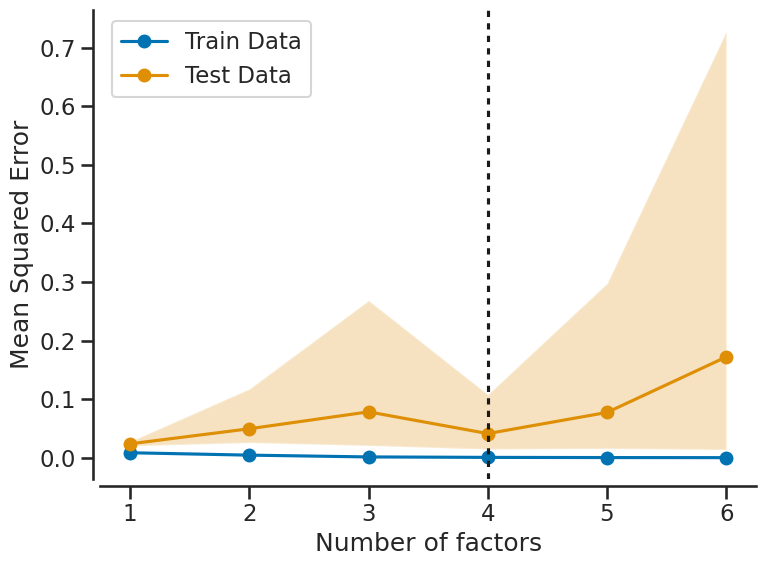

In [29]:
from scipy.signal import argrelextrema

fig, ax = plt.subplots(1, figsize=(8, 6))

ax.plot(groups["MSE"]["mean"]["Train"], 'o-', label="Train Data")
ax.plot(groups["MSE"]["mean"]["Test"], 'o-', label="Test Data")

ax.fill_between(groups["MSE"]["5%"]["Train"].index, groups["MSE"]["5%"]["Train"],
                groups["MSE"]["95%"]["Train"], alpha=0.25)
ax.fill_between(groups["MSE"]["5%"]["Test"].index, groups["MSE"]["5%"]["Test"],
                groups["MSE"]["95%"]["Test"], alpha=0.25)

test_mse = groups["MSE"]["mean"]["Test"].values
ranks = groups["MSE"]["mean"]["Test"].index.values

local_min_idx = argrelextrema(test_mse, np.less)[0]

if len(local_min_idx) > 0:
    inflection = ranks[local_min_idx[0]]
    ax.axvline(inflection, color='k', dashes=[2, 2])

sns.despine(offset=5)
ax.set_ylabel("Mean Squared Error")
ax.set_xlabel("Number of factors")
ax.legend()
plt.tight_layout()

N_FACTORS = 4

#####